In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import re

plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 10})

plt.rcParams["legend.frameon"] = False

In [2]:
def parse_data(target_loop_idx, params, 
               type_to_report = 'inner', 
               report_params=['volume_density'],
              metric='obs'):
    master_data = []
    ftags=[]

    for i, row in params.iterrows():
        f = os.path.join(basedir, params.loc[i, 'result_file'])
        basename = os.path.basename(f).replace('.tsv', '')
        row_dict = {}

        df = pd.read_csv(f, sep='\t')
        #print(df)
        if type_to_report == 'inner':
            loop_row = df[df['MM'] == 'inner'].iloc[target_loop_idx]
            if i == 0:
                print(df[df['MM'] == 'inner'])
        elif type_to_report == 'EP':
            loop_row = df[df['loop_type'] == 'EP'].iloc[target_loop_idx]
        elif type_to_report == 'outer':
            loop_row = df[df['MM'] == 'outer'].iloc[target_loop_idx]
            if i == 0:
                print(df[df['MM'] == 'outer'])
        elif type_to_report == 'CTCF_conv':
            loop_row = df[df['loop_type'] == 'CTCF_conv'].iloc[target_loop_idx]
            if pd.notna(loop_row['MM']):
                print("Warning: it's a MM loop")
        elif type_to_report == 'CTCF_other':
            loop_row = df[df['loop_type'] == 'CTCF_other'].iloc[target_loop_idx]
        row_dict['mean'] = loop_row[f'{metric}_mean']
        row_dict['se'] = loop_row[f'{metric}_se']
        master_data.append(row_dict)
        
        param_string=""
        for k in range(len(report_params)):
            param_string = f"{param_string}{params.loc[i, report_params[k]]}_"
        ftags.append(param_string)
    print(loop_row.left, loop_row.right)
    master_df = pd.DataFrame(master_data)
    master_df.index = ftags    
    
    return master_df, ftags


# def error_propagate_se(df, idx_control):
#     error_sq = (master_df['se']/master_df['mean'])**2
#     const_err = (master_df['se'].loc[idx_control]/master_df['mean'].loc[idx_control])**2
#     print(const_err)
#     fc_se = np.sqrt(error_sq.values + const_err)
    
#     return fc_se

def error_propagate_se(df, idx_control):
    error_sq = (master_df['se']/master_df['mean'])**2
    const_err = (master_df['se'].iloc[idx_control]/master_df['mean'].iloc[idx_control])**2
    fc_se = np.sqrt(error_sq.values + const_err)
    
    return fc_se

In [112]:
basedir = "/mnt/md1/varshini/Blood/sim_compaction_fountain_Ba."
params = pd.read_csv(os.path.join(basedir, "mapping.tsv"), sep="\t").replace(np.nan, 0)
params['volume_density'] =params['volume_density'].replace(0, 0.3)
#params = params[params['run_id']!='run_000'] # uncorrected density


In [113]:
#select = params[params['vel_steps']=='(0.0025, 50)']
#select = select[~select["original_path"].str.contains("/mnt/md1/varshini/Blood/sim_data_velocity/2026-04-26 17:37:59.846865")]

In [114]:
params

,run_id,sim_id,original_path,result_file,parameters_file,processivity,separations,ctcf_boost_factor,llp,h,loading_width,cohesins_per_mm,volume_density,vel_steps
0,run_000,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_000_sim_00_loops.tsv,run_000_sim_00_parameters.txt,300,240,4,2,0.4,16,64.0,0.15,"(0.0025, 50)"
1,run_000,sim_01,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_000_sim_01_loops.tsv,run_000_sim_01_parameters.txt,300,240,4,2,0.4,16,64.0,0.45,"(0.0025, 50)"
2,run_000,sim_02,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_000_sim_02_loops.tsv,run_000_sim_02_parameters.txt,300,240,4,2,0.4,16,64.0,0.60,"(0.0025, 50)"
3,run_001,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_001_sim_00_loops.tsv,run_001_sim_00_parameters.txt,300,240,4,2,0.4,16,0.0,0.60,"(0.0025, 50)"
4,run_002,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_002_sim_00_loops.tsv,run_002_sim_00_parameters.txt,300,240,4,2,0.4,4,64.0,0.60,"(0.0025, 50)"
5,run_003,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_003_sim_00_loops.tsv,run_003_sim_00_parameters.txt,300,240,4,2,0.4,16,128.0,0.60,"(0.0025, 50)"
6,run_004,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_004_sim_00_loops.tsv,run_004_sim_00_parameters.txt,300,240,4,2,0.4,16,128.0,0.30,"(0.0025, 50)"
7,run_005,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_005_sim_00_loops.tsv,run_005_sim_00_parameters.txt,300,240,4,2,0.4,4,64.0,0.15,"(0.0025, 50)"
8,run_005,sim_01,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_005_sim_01_loops.tsv,run_005_sim_01_parameters.txt,300,240,4,2,0.4,4,64.0,0.30,"(0.0025, 50)"
9,run_006,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_006_sim_00_loops.tsv,run_006_sim_00_parameters.txt,300,240,4,2,0.4,4,64.0,0.30,"(0.0025, 50)"


In [115]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v3/sim_loop_strengths/"

In [116]:
select = params[((params['cohesins_per_mm']==64) | (params['cohesins_per_mm']==0) | (params['cohesins_per_mm']==256)) 
                & (params['volume_density']==0.3)]


In [117]:
params

,run_id,sim_id,original_path,result_file,parameters_file,processivity,separations,ctcf_boost_factor,llp,h,loading_width,cohesins_per_mm,volume_density,vel_steps
0,run_000,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_000_sim_00_loops.tsv,run_000_sim_00_parameters.txt,300,240,4,2,0.4,16,64.0,0.15,"(0.0025, 50)"
1,run_000,sim_01,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_000_sim_01_loops.tsv,run_000_sim_01_parameters.txt,300,240,4,2,0.4,16,64.0,0.45,"(0.0025, 50)"
2,run_000,sim_02,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_000_sim_02_loops.tsv,run_000_sim_02_parameters.txt,300,240,4,2,0.4,16,64.0,0.60,"(0.0025, 50)"
3,run_001,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_001_sim_00_loops.tsv,run_001_sim_00_parameters.txt,300,240,4,2,0.4,16,0.0,0.60,"(0.0025, 50)"
4,run_002,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_002_sim_00_loops.tsv,run_002_sim_00_parameters.txt,300,240,4,2,0.4,4,64.0,0.60,"(0.0025, 50)"
5,run_003,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_003_sim_00_loops.tsv,run_003_sim_00_parameters.txt,300,240,4,2,0.4,16,128.0,0.60,"(0.0025, 50)"
6,run_004,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_004_sim_00_loops.tsv,run_004_sim_00_parameters.txt,300,240,4,2,0.4,16,128.0,0.30,"(0.0025, 50)"
7,run_005,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_005_sim_00_loops.tsv,run_005_sim_00_parameters.txt,300,240,4,2,0.4,4,64.0,0.15,"(0.0025, 50)"
8,run_005,sim_01,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_005_sim_01_loops.tsv,run_005_sim_01_parameters.txt,300,240,4,2,0.4,4,64.0,0.30,"(0.0025, 50)"
9,run_006,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_006_sim_00_loops.tsv,run_006_sim_00_parameters.txt,300,240,4,2,0.4,4,64.0,0.30,"(0.0025, 50)"


In [142]:
os.mkdir(savedir)

    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
8            8   330    574  CTCF_conv  inner         8  0.104673  0.001275   
17          17   724   1241  CTCF_conv  inner        17  0.026035  0.000550   
25          25  1433   1580  CTCF_conv  inner        25  0.165137  0.001772   

     oe_mean     oe_se  
8   8.415469  0.116917  
17  6.016825  0.158933  
25  7.466324  0.088817  
330 574


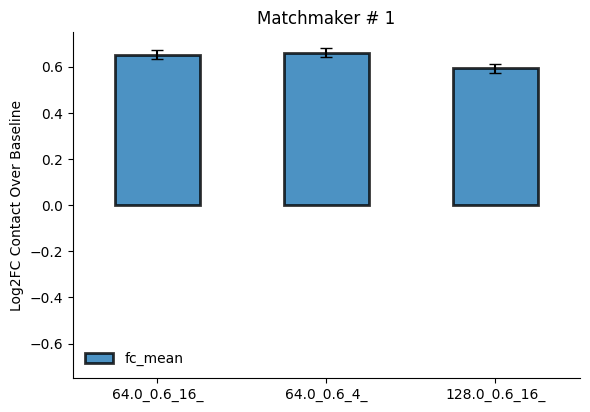

In [143]:
# inner 
order = select.reset_index().index
order = [2, 4, 5]
for idx in [0]:
    master_df, ftags = parse_data(idx, params, type_to_report='inner', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(6, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    plt.ylim([-0.75, 0.75])
    plt.tight_layout()
    
    plt.title(f"Matchmaker # {idx + 1}")
    plt.savefig(os.path.join(savedir, f"inner_loop{idx}_density.svg"))
    
    plt.show()


In [119]:
master_df

,mean,se,fc_mean,propagated_se
64.0_0.15_16_,0.104673,0.001275,0.083604,0.018523
64.0_0.45_16_,0.135926,0.001499,0.460539,0.017786
64.0_0.6_16_,0.155176,0.002111,0.651619,0.019486
0.0_0.6_16_,0.131261,0.001905,0.410154,0.020132
64.0_0.6_4_,0.156083,0.002252,0.660028,0.020070
128.0_0.6_16_,0.149003,0.002120,0.593061,0.019928
128.0_0.3_16_,0.145010,0.001732,0.553873,0.018368
64.0_0.15_4_,0.108264,0.001750,0.132267,0.021350
64.0_0.3_4_,0.125328,0.001638,0.343426,0.019118
64.0_0.3_4_,0.111822,0.001480,0.178919,0.019234


    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
1            1   200    694  CTCF_conv  outer         1  0.075738  0.001303   
12          12   330   1390  CTCF_conv  outer        12  0.003040  0.000215   
23          23  1425   1752  CTCF_conv  outer        23  0.058906  0.000906   

      oe_mean     oe_se  
1   15.018605  0.342199  
12   3.355244  0.255211  
23   7.316046  0.127246  
200 694


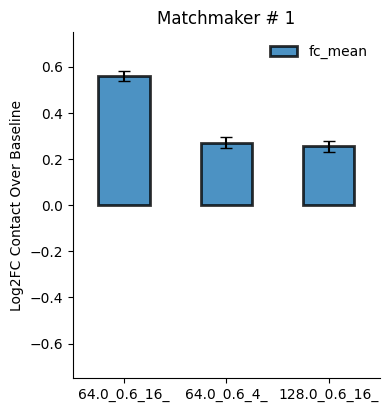

In [144]:
idx = 0
master_df, ftags = parse_data(idx, params, type_to_report='outer', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='obs')

idx_control=-1
order = [2, 4, 5]

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.iloc[order, :].plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(4, 4),
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
plt.ylim([-0.75, 0.75])
plt.tight_layout()
plt.title(f"Matchmaker # {idx + 1}")
plt.savefig(os.path.join(savedir, f"outer_loop{idx}_density.svg"))
plt.show()

In [121]:
idx = 0
master_df, ftags = parse_data(idx, select, type_to_report='inner', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='obs')

idx_control=-1

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.iloc[order, :].plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(5, 4)
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
#plt.ylim([0, 0.25])
plt.tight_layout()
#plt.savefig(os.path.join(savedir, f"loop_{loop_idx}_fc.svg"))
plt.title(f"Matchmaker # {idx + 1}")
plt.ylim([-0.75, 0.75])
#plt.savefig(os.path.join(savedir, f"outer_loop{idx}_density.svg"))

plt.show()

330 574


IndexError: positional indexers are out-of-bounds

In [122]:
select = params[((params['cohesins_per_mm']==64) & (params['loading_width']==16)) | 
                ((params['cohesins_per_mm']==0) )]


In [123]:
params

,run_id,sim_id,original_path,result_file,parameters_file,processivity,separations,ctcf_boost_factor,llp,h,loading_width,cohesins_per_mm,volume_density,vel_steps
0,run_000,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_000_sim_00_loops.tsv,run_000_sim_00_parameters.txt,300,240,4,2,0.4,16,64.0,0.15,"(0.0025, 50)"
1,run_000,sim_01,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_000_sim_01_loops.tsv,run_000_sim_01_parameters.txt,300,240,4,2,0.4,16,64.0,0.45,"(0.0025, 50)"
2,run_000,sim_02,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_000_sim_02_loops.tsv,run_000_sim_02_parameters.txt,300,240,4,2,0.4,16,64.0,0.60,"(0.0025, 50)"
3,run_001,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_001_sim_00_loops.tsv,run_001_sim_00_parameters.txt,300,240,4,2,0.4,16,0.0,0.60,"(0.0025, 50)"
4,run_002,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_002_sim_00_loops.tsv,run_002_sim_00_parameters.txt,300,240,4,2,0.4,4,64.0,0.60,"(0.0025, 50)"
5,run_003,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_003_sim_00_loops.tsv,run_003_sim_00_parameters.txt,300,240,4,2,0.4,16,128.0,0.60,"(0.0025, 50)"
6,run_004,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_004_sim_00_loops.tsv,run_004_sim_00_parameters.txt,300,240,4,2,0.4,16,128.0,0.30,"(0.0025, 50)"
7,run_005,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_005_sim_00_loops.tsv,run_005_sim_00_parameters.txt,300,240,4,2,0.4,4,64.0,0.15,"(0.0025, 50)"
8,run_005,sim_01,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_005_sim_01_loops.tsv,run_005_sim_01_parameters.txt,300,240,4,2,0.4,4,64.0,0.30,"(0.0025, 50)"
9,run_006,sim_00,/mnt/md1/varshini/Blood/sim_data_density_subse...,run_006_sim_00_loops.tsv,run_006_sim_00_parameters.txt,300,240,4,2,0.4,4,64.0,0.30,"(0.0025, 50)"


    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
1            1   200    694  CTCF_conv  outer         1  0.075738  0.001303   
12          12   330   1390  CTCF_conv  outer        12  0.003040  0.000215   
23          23  1425   1752  CTCF_conv  outer        23  0.058906  0.000906   

      oe_mean     oe_se  
1   15.018605  0.342199  
12   3.355244  0.255211  
23   7.316046  0.127246  
200 694


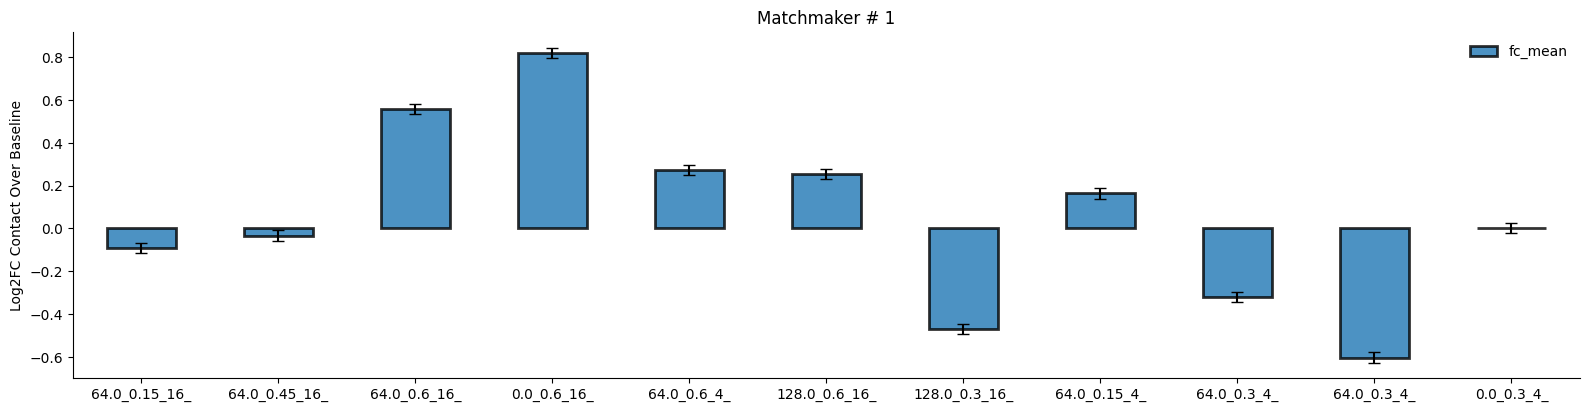

In [124]:
# inner: increased cohesin volume density 
order = [0, 3, 1, 2]
for idx in [0]:
    master_df, ftags = parse_data(idx, params, type_to_report='outer', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[:, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(16, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    #plt.ylim([-0.75, 0.75])
    #plt.savefig(os.path.join(savedir, f"inner_loop{idx}_density.svg"))
    plt.show()


250 540


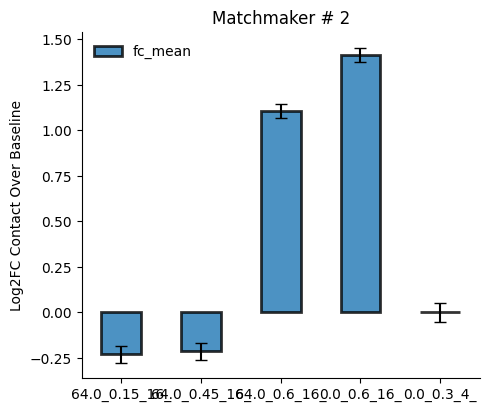

In [125]:
idx = 1
master_df, ftags = parse_data(idx, select, type_to_report='EP', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='obs')

idx_control=-1

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.iloc[:, :].plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(5, 4)
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
#plt.ylim([0, 0.25])
plt.tight_layout()
#plt.savefig(os.path.join(savedir, f"loop_{loop_idx}_fc.svg"))
plt.title(f"Matchmaker # {idx + 1}")
#plt.ylim([-0.75, 0.75])
#plt.savefig(os.path.join(savedir, f"outer_loop{idx}_density.svg"))

plt.show()

    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
1            1   200    694  CTCF_conv  outer         1  0.075738  0.001303   
12          12   330   1390  CTCF_conv  outer        12  0.003040  0.000215   
23          23  1425   1752  CTCF_conv  outer        23  0.058906  0.000906   

      oe_mean     oe_se  
1   15.018605  0.342199  
12   3.355244  0.255211  
23   7.316046  0.127246  
200 694


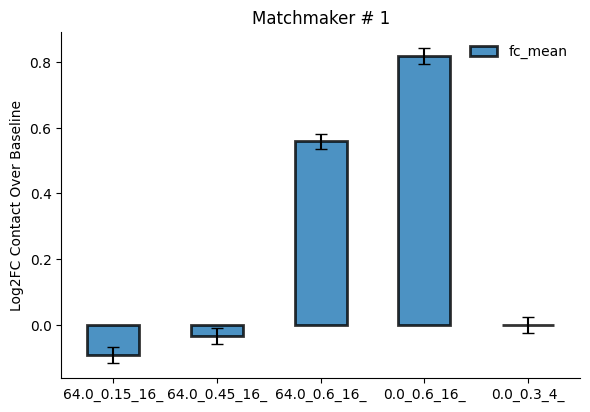

In [126]:
idx = 0
master_df, ftags = parse_data(idx, select, type_to_report='outer', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='obs')

idx_control=-1

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.iloc[:, :].plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(6, 4)
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
#plt.ylim([0, 0.25])
plt.tight_layout()
#plt.savefig(os.path.join(savedir, f"loop_{loop_idx}_fc.svg"))
plt.title(f"Matchmaker # {idx + 1}")
#plt.ylim([-0.75, 0.75])
#plt.savefig(os.path.join(savedir, f"outer_loop{idx}_density.svg"))

plt.show()

## Other targeted loading sites for supp 11

In [127]:
select = params[((params['cohesins_per_mm']==64) | (params['cohesins_per_mm']==0) | (params['cohesins_per_mm']==256)) 
                & (params['volume_density']==0.3)]


    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
8            8   330    574  CTCF_conv  inner         8  0.104673  0.001275   
17          17   724   1241  CTCF_conv  inner        17  0.026035  0.000550   
25          25  1433   1580  CTCF_conv  inner        25  0.165137  0.001772   

     oe_mean     oe_se  
8   8.415469  0.116917  
17  6.016825  0.158933  
25  7.466324  0.088817  
724 1241


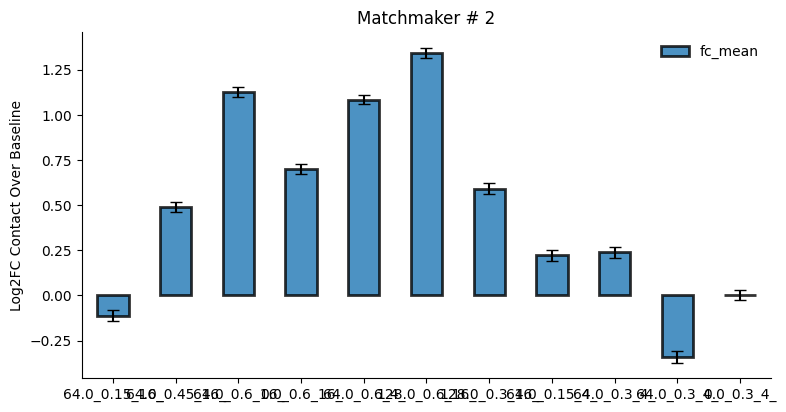

    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
8            8   330    574  CTCF_conv  inner         8  0.104673  0.001275   
17          17   724   1241  CTCF_conv  inner        17  0.026035  0.000550   
25          25  1433   1580  CTCF_conv  inner        25  0.165137  0.001772   

     oe_mean     oe_se  
8   8.415469  0.116917  
17  6.016825  0.158933  
25  7.466324  0.088817  
1433 1580


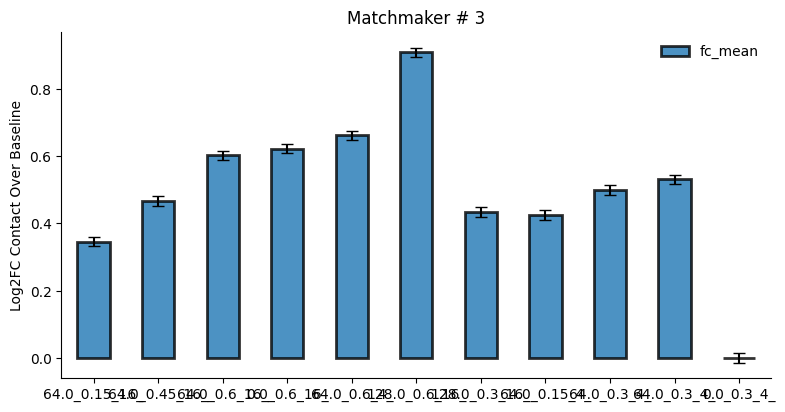

In [130]:
# inner: increased cohesin volume density 
order = [3,  1, 2, 0]
for idx in [1,2]:
    master_df, ftags = parse_data(idx, params, type_to_report='inner', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[:, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(8, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    #plt.ylim([-1.5, 1.5])
    #plt.savefig(os.path.join(savedir, f"inner_loop{idx}_loading.svg"))
    plt.show()



1425 1752


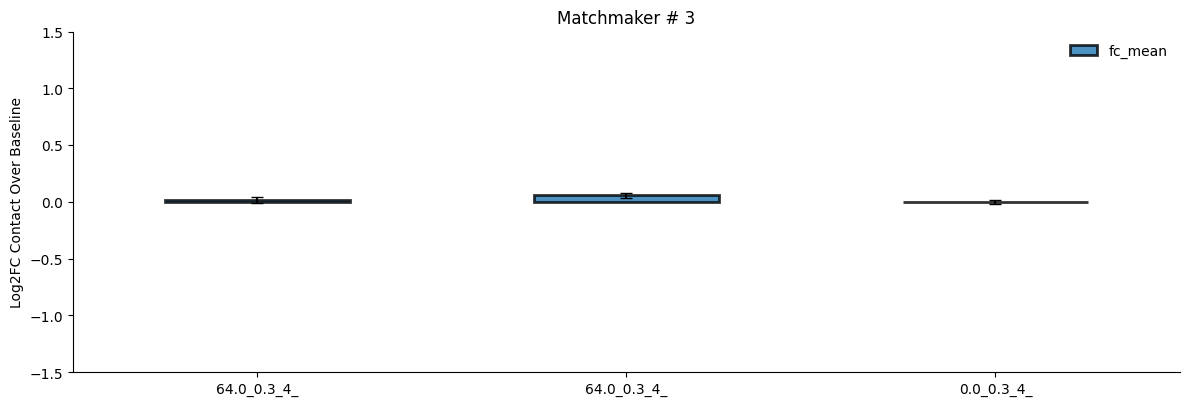

In [132]:
# outer 
order = select.reset_index().index
for idx in [2]:
    master_df, ftags = parse_data(idx, select, type_to_report='outer', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[:, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(12, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    plt.ylim([-1.5, 1.5])
    plt.tight_layout()
    
    plt.title(f"Matchmaker # {idx + 1}")
    #plt.savefig(os.path.join(savedir, f"outer_loop{idx}_loading.svg"))
    
    plt.show()

In [133]:
# inner: increased cohesin volume density 
order = [0, 3, 1, 2]
for idx in [18]:
    master_df, ftags = parse_data(idx, select, type_to_report='CTCF_conv', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(5, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    plt.ylim([-1.5, 1.5])
    #plt.savefig(os.path.join(savedir, f"inner_loop{idx}_density.svg"))
    plt.show()


724 1390


IndexError: positional indexers are out-of-bounds

In [43]:
# now density sweep

In [44]:
select = params[((params['cohesins_per_mm']==64) & (params['loading_width']==16)) | 
                ((params['cohesins_per_mm']==0) & (params['loading_width']==4))]


    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
8            8   330    574  CTCF_conv  inner         8  0.104673  0.001275   
17          17   724   1241  CTCF_conv  inner        17  0.026035  0.000550   
25          25  1433   1580  CTCF_conv  inner        25  0.165137  0.001772   

     oe_mean     oe_se  
8   8.415469  0.116917  
17  6.016825  0.158933  
25  7.466324  0.088817  
724 1241


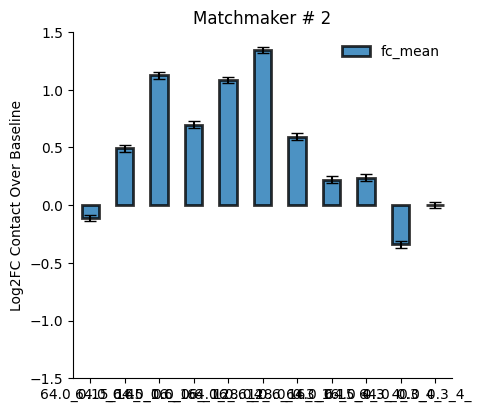

    Unnamed: 0  left  right  loop_type     MM  loop_idx  obs_mean    obs_se  \
8            8   330    574  CTCF_conv  inner         8  0.104673  0.001275   
17          17   724   1241  CTCF_conv  inner        17  0.026035  0.000550   
25          25  1433   1580  CTCF_conv  inner        25  0.165137  0.001772   

     oe_mean     oe_se  
8   8.415469  0.116917  
17  6.016825  0.158933  
25  7.466324  0.088817  
1433 1580


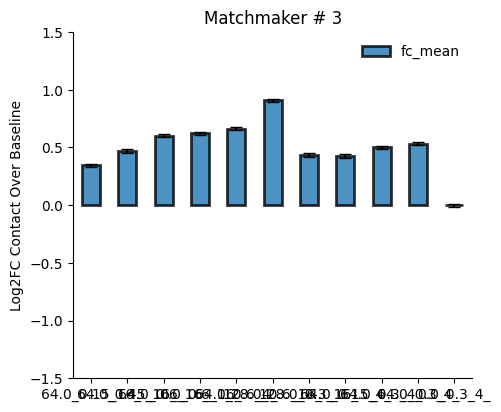

In [135]:
# inner: increased cohesin volume density 
order = [0, 3, 1, 2]
for idx in [1,2]:
    master_df, ftags = parse_data(idx, params, type_to_report='inner', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[:, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(5, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    plt.ylim([-1.5, 1.5])
    #plt.savefig(os.path.join(savedir, f"inner_loop{idx}_density.svg"))
    plt.show()



200 330


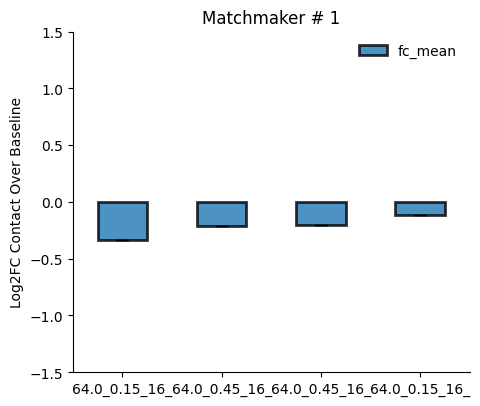

In [46]:
# inner: increased cohesin volume density 
order = [0, 3, 1, 2]
for idx in [0]:
    master_df, ftags = parse_data(idx, select, type_to_report='CTCF_other', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(5, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    plt.ylim([-1.5, 1.5])
    #plt.savefig(os.path.join(savedir, f"inner_loop{idx}_density.svg"))
    plt.show()
